## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 3 

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100**</font> possible on this quiz and each part of the quiz can be done independently. **If you get stuck _move on to another part of the quiz to earn some points there!_**

---
# Part 1:  Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

**NOTE: If you use generative AI, you must copy/paste into a cell in this quiz (1) your prompt, (2) the output from chatGPT, (3)helpfulness rating of AI response (1 to 7, 1 being Not helpful at all and 7 being Extremely helpful), and (4) Write your answer in separate cells. Failure to include this level of detail will result in a deduction of points.**

<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 2: Reading, describing, and exploring the credit data (50 points total)

As a data analyst newly hired at a leading education research organization, you have been tasked with analyzing factors that influence student performance in exams. To begin this exploration, you will be examining the ["StudentsPerformance.csv" dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/data), a comprehensive dataset containing anonymized records of students, including demographic information, parental education levels, lunch type, test preparation course completion, and scores in math, reading, and writing.


#### &#9989;&nbsp; **Question 2.1 (5 points)** 

Load the `StudentsPerformance.csv` file provided **using Pandas** and display the first 10 rows.




In [2]:
# Let's make sure pandas is imported
import pandas as pd

# Put your code here


#### &#9989;&nbsp; **Question 2.2**  (15 points)

Using the provided dataset, `StudentsPerformance.csv`, your goal is to explore how various factors influence student achievement and to identify patterns that may help improve future educational outcomes.

The `pandas` DataFrame you created should include the following columns:

* **'gender'** – Gender of the student  
* **'race/ethnicity'** – Group classification of the student  
* **'parental level of education'** – Highest education level attained by the parents  
* **'lunch'** – Type of lunch received (standard or free/reduced)  
* **'test preparation course'** – Completion status of the test preparation course (`completed` or `none`)  
* **'math score'** – Score on the math exam  
* **'reading score'** – Score on the reading exam  
* **'writing score'** – Score on the writing exam  

---

### Task

You will now focus on whether completing a **test preparation course** affects student performance.

1. Create a **mask** that filters the dataset to include only students who **completed** the test preparation course.  
2. **Display the resulting DataFrame** to confirm that you applied the filter correctly.  
---

**Note:**  
If you were unable to load the dataset successfully, you may still receive partial credit by writing the **correct code** that would perform this filtering.


In [4]:
# Put your code here


#### &#9989;&nbsp; **Question 2.3 (10 points)**

Now that you’ve filtered your dataset to include only students who **completed the test preparation course**, you are curious about how well this group performs academically.

Write code to calculate and display the **mean math score** (the `'math score'` column) for the filtered DataFrame you created in the previous question.

You may also choose to calculate the mean for the **reading** or **writing** scores if you prefer.

**Note #1:** There’s more than one valid way to solve this.  

**Note #2:** If you didn’t get the dataset loaded or filtered correctly, try your best to write the code that **should** calculate and display the mean for partial credit.


In [10]:
# Put your code here


From the output of your code, what is the mean math score for the specified group?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

#### &#9989;&nbsp; **Question 2.4 Documenting Your Solution Pathway (20 points)**

**Describe in detail** how you solved the problem including any external resources you consulted (e.g. generative AI **prompts and outputs**, past assignments, Code Portfolio, Stack Overflow, Google, etc.) and how they informed your approach. You must also describe how you know your solution works (e.g. and calculations you made, tests you ran, etc.)

If you used generative AI, please answer the questions in a separate cell as specified in Part 0.

If you did not use external resources, describe your thought process for solving the problem by answering the following questions:
1. How did you know where to start?
2. What prior knowledge did you recall to solve the problem?
3. How do you know that your solution works?

<font size=+3>&#9998;</font> *Put your answer here.*

---
# 3. Fitting a model to data with `curve_fit` and visualizing the results (40 points)

We have studied building ordinary differential equations (ODEs) and solving them by `solve_ivp`. Using `curve_fit` to fit the numerical solution can always inspire us to find the true solution. 
Now we have the following differential equation:
$$ \frac{dv}{dt} =5\sin(7t)dt$$
with the initial $v(0) =1.0$. Using the code below you can find the numerical solution `y_values` on the time interval $[0,10]$. Try to fit these data and test your final analytic solution.

Text(0, 0.5, 'y_solution')

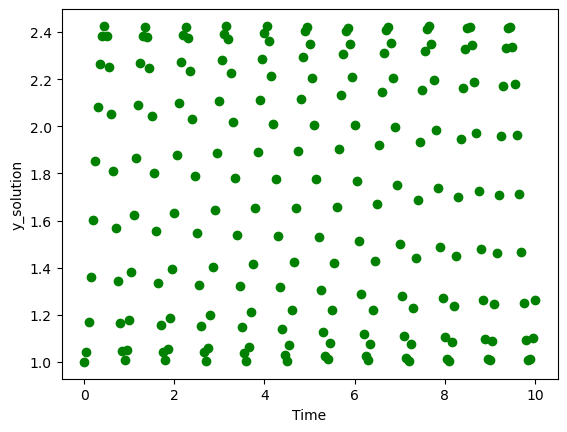

In [4]:
## DO NOT DELETE THE PROVIDED LINES OF CODE

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp

# Define a function that computes the derivatives
def derivatives(t, curr_vals):
    v = curr_vals
    
    dvdt = 5*np.sin(7*t)
    
    #return the derivatives
    return dvdt

# Define initial conditions
t = 0.0
v = 1.0

# Define the final time and the time step
final_time = 10.0
delta_t = 0.05

# Define some lists to store values
time = []
y_values = []

    
# Define the time array
time = np.arange(0, final_time + delta_t, delta_t)

# Store the initial values in a list
init = [v]

# Solve the odes with solve_ivp
sol = solve_ivp(derivatives, (t,final_time),init,t_eval = time)

#length = sol.y[0,:]
y_values = sol.y[0,:]
    
# Make a plot of the result in two different matplotlib figures
# Of course, this could also be done with subplots
fig1 = plt.figure(1)
plt.scatter(time,y_values, color="green")
plt.xlabel("Time")
plt.ylabel("y_solution")

---

#### &#9989;&nbsp; **Question 3.1 (10 points):** 

Using the time array `time` and numerical solution `y_values` data and provided model below, use `curve_fit` to find best fit parameters for *a, b,* and *c*. Make sure you give `curve_fit` a good starting point for finding the best fit parameters using the `p0` argument and these starting values:
* a = 5
* b = 7
* c = 0

Once you've found the best values, **print them out**. You should find that they are not far off from, but not the same as, the original values provided.

In [5]:
## DO NOT DELETE THE PROVIDED LINES OF CODE
# Will need to use NumPy for the function
import numpy as np

# Will need to import curve_fit from SciPy
from scipy.optimize import curve_fit

# This function calculates volts corresponding to the time for a sound wave
def cos_wave(t,a,b,c):
    return a*np.cos(b*t)+c

In [6]:
# Put your code here


#### &#9989;&nbsp; **Question 3.2 (10 points)** 

Now that you have a set of best fit parameters, **use those parameters to calculate the expected model values and plot the expected model values on top of the actual data values**. Make sure to label your axes and include a legend to communicate what parts of the plot correspond to the model versus the data.

In [8]:
# Make sure we import matplotlib
import matplotlib.pyplot as plt

# Put your code here

#### &#9989;&nbsp; **Question 3.3 Documenting Your Solution Pathway (20 points)**

**Describe in detail** how you solved the problem including any external resources you consulted (e.g. generative AI **prompts and outputs**, past assignments, Code Portfolio, Stack Overflow, Google, etc.) and how they informed your approach. You must also describe how you know your solution works (e.g. and calculations you made, tests you ran, etc.)

If you used generative AI, please answer the questions in a separate cell as specified in Part 0.

If you did not use external resources, describe your thought process for solving the problem by answering the following questions:
1. How did you know where to start?
2. What prior knowledge did you recall to solve the problem?
3. How do you know that your solution works?

<font size=+3>&#9998;</font> *Put your answer here.*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #3, and upload it there.